# Experiment 4: Lemmatization — Character-level Seq2Seq
## Does writing-system representation affect morphological analysis?

**Task:** Given an inflected Elamite word, predict its base lemma.
- Input: `h hi bat tin na` (Latin) or `𒀸 𒄭 𒁁 𒁷 𒈾` (Unicode)
- Target: `hibat` (the base lemma from the dictionary)

**Models:**
1. LSTM seq2seq with Bahdanau attention (baseline)
2. Character-level Transformer encoder-decoder (primary)

**This notebook runs AFTER v3.** It assumes the preprocessing cells from v3 have been run.
If running standalone, include Sections 0-1 from v3 first.

**Run on GPU** (Colab: Runtime → Change runtime type → GPU)

In [7]:
# ============================================================
# 0. SETUP
# ============================================================
!pip install -q gensim scikit-learn matplotlib seaborn pandas openpyxl regex torch

import pandas as pd
import numpy as np
import regex as re
import math, os, json
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [8]:
# ============================================================
# 0b. MOUNT & LOAD (same as v3)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = 'data/'
DICT_PATH = BASE_PATH + 'Elamite_Lemma-base-draft.xlsx'
UNMATCHED_PATH_1 = BASE_PATH + 'unmatchednew_AAedit - unmatchednew.csv'
UNMATCHED_PATH_2 = BASE_PATH + 'unmatchednew - solonew.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# ============================================================
# 1. REPRODUCE PREPROCESSING (condensed from v3)
# ============================================================
all_sheets = pd.read_excel(DICT_PATH, sheet_name=None)
target_tabs = ['ADJ', 'Noun', 'Verb', 'other', 'PN', 'PN-hyp', 'GN', 'DN', 'Magic']
columns_to_keep = [
    'transliteration', 'sorting', 'period', 'base',
    'logogram', 'morpheme_1', 'morpheme_2', 'morpheme_3',
    'sense_hk', 'certainty-weight_hk', 'sense_hk_qid',
    'certainty-weight_MEGA', 'sense_MEGA_qid', 'POS', 'number', 'person'
]
combined = []
for name in target_tabs:
    if name in all_sheets:
        df = all_sheets[name]; df['category'] = name
        existing = [c for c in columns_to_keep if c in df.columns]
        combined.append(df[existing + ['category']])
final_dictionary = pd.concat(combined, ignore_index=True)

# Sign lists
sign_list = pd.read_json('https://raw.githubusercontent.com/situx/Nuolenna/master/sign_list.json', orient='index')
sign_list.columns = ['unicode']; sign_list['sign'] = sign_list.index.tolist()
sign_list = sign_list[['sign','unicode']].reset_index(drop=True)
akkademia = pd.read_csv('https://raw.githubusercontent.com/gaigutherz/Akkademia/master/cuneiform_to_unicode_fixed.csv')
concatenated = pd.merge(sign_list, akkademia, on=['sign','unicode'], how='outer', indicator=True)

unmatched = pd.read_csv(UNMATCHED_PATH_1)[['unmatched_sign','use']].dropna()
unmatched2 = pd.read_csv(UNMATCHED_PATH_2)[['value','SIGN']].dropna()
manual_dict = dict(zip(unmatched['unmatched_sign'], unmatched['use']))
manual_dict2 = dict(zip(unmatched2['value'].str.strip("[]' "), unmatched2['SIGN']))
unicode_dict = dict(zip(concatenated['sign'], concatenated['unicode']))
unicode_dict.update(manual_dict); unicode_dict.update(manual_dict2)

# Preprocessing functions
def normalize_for_unmatched_pass(s):
    if pd.isna(s): return ""
    s = str(s)
    s = re.sub(r"\(\s*md\s*\)", " m d ", s)
    s = re.sub(r"[.,:;!?()\[\]{}<>\\\"\"\"''/\\|*^`~]", " ", s)
    s = re.sub(r"[-\u2013\u2014]", " ", s)
    s = re.sub(r"([A-Za-z])(\d)([A-Za-z])", r"\1\2 \3", s)
    s = re.sub(r"(\d)([A-Za-z])", r"\1 \2", s)
    return re.sub(r"\s+", " ", s).strip()

unicode_dict_v2 = dict(zip(concatenated['sign'].astype(str), concatenated['unicode'].astype(str)))
unicode_dict_v2.update(manual_dict); unicode_dict_v2.update(manual_dict2)

def replace_with_unicode(text):
    return ' '.join([unicode_dict.get(s, s) for s in text.split()])

def final_unmatched_conversion_pass(unicode_text):
    txt = normalize_for_unmatched_pass(unicode_text)
    tokens = txt.split()
    out, unm = [], []
    for tok in tokens:
        if tok == 'md' and 'm' in unicode_dict_v2 and 'd' in unicode_dict_v2 and 'md' not in unicode_dict_v2:
            out.append(unicode_dict_v2['m']); out.append(unicode_dict_v2['d']); continue
        if tok in unicode_dict_v2: out.append(unicode_dict_v2[tok])
        else:
            out.append(tok)
            if re.search(r'\p{Latin}', tok): unm.append(tok)
    return ' '.join(out), unm

# Apply full pipeline
to_unicode = final_dictionary.copy()
to_unicode['transliteration original'] = to_unicode['transliteration']
to_unicode['transliteration'] = to_unicode['transliteration'].astype(str).fillna('')
to_unicode['transliteration'] = to_unicode['transliteration'].str.replace('-', ' ')
for ch in ['_','[',']','*','!','?','/',',',':',';','^','`']:
    to_unicode['transliteration'] = to_unicode['transliteration'].str.replace(ch, '', regex=False)
to_unicode['transliteration'] = to_unicode['transliteration'].str.replace('.', ' ', regex=False)
to_unicode['transliteration'] = to_unicode['transliteration'].str.lower()
to_unicode['transliteration'] = to_unicode['transliteration'].str.replace(r'~.*?……', '……', regex=True)
to_unicode['transliteration'] = to_unicode['transliteration'].str.replace('X', '', regex=False)
to_unicode['transliteration'] = to_unicode['transliteration'].str.replace('……', ' ', regex=False)
to_unicode['unicode'] = to_unicode['transliteration'].apply(replace_with_unicode)

tmp = to_unicode['unicode'].apply(final_unmatched_conversion_pass)
to_unicode['transliteration'] = to_unicode['transliteration original'].apply(normalize_for_unmatched_pass)
to_unicode['roman'] = tmp.apply(lambda x: len(x[1]) > 0)
to_unicode['unicode'] = tmp.apply(lambda x: x[0])

dict_clean = to_unicode[to_unicode['roman'] == False].copy()
dict_clean['repr_latin'] = dict_clean['transliteration']
dict_clean['repr_unicode'] = dict_clean['unicode']
print(f'Clean entries: {len(dict_clean)} ({len(dict_clean)/len(to_unicode)*100:.1f}%)')

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Clean entries: 13383 (85.8%)


In [10]:
# ============================================================
# 2. PREPARE LEMMATIZATION PAIRS
# ============================================================
# Source: transliteration (inflected form) → base (lemma)
# We create pairs for both Latin and Unicode representations

lemma_data = dict_clean[['repr_latin', 'repr_unicode', 'base', 'category']].copy()
lemma_data = lemma_data.dropna(subset=['base'])
lemma_data = lemma_data[lemma_data['base'].str.strip() != '']
lemma_data = lemma_data[lemma_data['repr_latin'].str.strip() != '']
lemma_data = lemma_data.drop_duplicates(subset=['repr_latin', 'base'])
lemma_data = lemma_data.reset_index(drop=True)
lemma_data['base'] = lemma_data['base'].astype(str)
all_targets = lemma_data['base'].tolist()

print(f'Lemmatization pairs: {len(lemma_data)}')
print(f'By POS: {lemma_data["category"].value_counts().to_dict()}')
print()

# Show examples
print('=== Sample pairs ===')
for _, r in lemma_data.head(10).iterrows():
    print(f'  Latin: {r["repr_latin"]:30s} → {r["base"]:15s} [{r["category"]}]')
    print(f'  Unicode: {r["repr_unicode"]:30s} → {r["base"]}')
    print()

Lemmatization pairs: 1794
By POS: {'Noun': 792, 'ADJ': 518, 'Verb': 468, 'other': 16}

=== Sample pairs ===
  Latin: a a                            → ai              [ADJ]
  Unicode: 𒀀 𒀀                            → ai

  Latin: h hi bat tin na                → Hipat           [ADJ]
  Unicode: 𒀸 𒄭 𒁁 𒁷 𒈾                      → Hipat

  Latin: v ha ak qa man nu iš ši ya     → hakamanušiya    [ADJ]
  Unicode: 𒁹 𒄩 𒀝 𒋡 𒌋𒌋 𒉡 𒅖 𒅆 𒉿             → hakamanušiya

  Latin: am mín nu                      → aminu           [ADJ]
  Unicode: 𒄠 𒊩 𒉡                          → aminu

  Latin: te man na na                   → tema (?)        [ADJ]
  Unicode: 𒋼 𒌋𒌋 𒈾 𒈾                       → tema (?)

  Latin: te na                          → te              [ADJ]
  Unicode: 𒋼 𒈾                            → te

  Latin: lag gi ma na                   → laki-           [ADJ]
  Unicode: 𒋃 𒄀 𒈠 𒈾                        → laki-

  Latin: la gi                          → laki-           [ADJ]
  Unicode: 𒆷 𒄀     

In [11]:
# ============================================================
# 3. VOCABULARY & DATASET
# ============================================================

class Seq2SeqVocab:
    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    def __init__(self):
        self.char2idx = {'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3}
        self.idx2char = {0: '<pad>', 1: '<sos>', 2: '<eos>', 3: '<unk>'}

    def build(self, texts):
        for text in texts:
            for ch in text:
                if ch not in self.char2idx:
                    idx = len(self.char2idx)
                    self.char2idx[ch] = idx
                    self.idx2char[idx] = ch
        return self

    def encode(self, text, max_len, add_eos=True):
        ids = [self.char2idx.get(ch, self.UNK) for ch in text]
        if add_eos:
            ids.append(self.EOS)
        ids = ids[:max_len]
        ids += [self.PAD] * (max_len - len(ids))
        return ids

    def decode(self, ids):
        chars = []
        for idx in ids:
            if idx == self.EOS: break
            if idx == self.PAD: continue
            if idx == self.SOS: continue
            chars.append(self.idx2char.get(idx, '?'))
        return ''.join(chars)

    def __len__(self):
        return len(self.char2idx)


class LemmaDataset(Dataset):
    def __init__(self, sources, targets, src_vocab, tgt_vocab, src_max, tgt_max):
        self.sources = sources
        self.targets = targets
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.src_max = src_max
        self.tgt_max = tgt_max

    def __len__(self): return len(self.sources)

    def __getitem__(self, idx):
        src = torch.tensor(self.src_vocab.encode(self.sources[idx], self.src_max), dtype=torch.long)
        tgt = torch.tensor(self.tgt_vocab.encode(self.targets[idx], self.tgt_max), dtype=torch.long)
        return src, tgt


# Build vocabularies
all_latin = lemma_data['repr_latin'].tolist()
all_unicode = lemma_data['repr_unicode'].tolist()
all_targets = lemma_data['base'].tolist()

src_vocab_latin = Seq2SeqVocab().build(all_latin)
src_vocab_unicode = Seq2SeqVocab().build(all_unicode)
tgt_vocab = Seq2SeqVocab().build(all_targets)

SRC_MAX = min(120, max(len(t) for t in all_latin + all_unicode) + 2)
TGT_MAX = min(60, max(len(t) for t in all_targets) + 2)

print(f'Latin vocab: {len(src_vocab_latin)} chars')
print(f'Unicode vocab: {len(src_vocab_unicode)} chars')
print(f'Target vocab: {len(tgt_vocab)} chars')
print(f'Max src len: {SRC_MAX}, max tgt len: {TGT_MAX}')

Latin vocab: 61 chars
Unicode vocab: 160 chars
Target vocab: 73 chars
Max src len: 32, max tgt len: 24


In [12]:
# ============================================================
# 4. MODEL 1: LSTM SEQ2SEQ WITH ATTENTION (BASELINE)
# ============================================================

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, batch_first=True,
                           bidirectional=True, dropout=dropout if n_layers > 1 else 0)
        self.fc_h = nn.Linear(hid_dim * 2, hid_dim)
        self.fc_c = nn.Linear(hid_dim * 2, hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.rnn(embedded)
        # Merge bidirectional
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        cell = torch.cat([cell[-2], cell[-1]], dim=1)
        hidden = torch.tanh(self.fc_h(hidden)).unsqueeze(0)
        cell = torch.tanh(self.fc_c(cell)).unsqueeze(0)
        return outputs, hidden, cell


class Attention(nn.Module):
    def __init__(self, enc_hid, dec_hid):
        super().__init__()
        self.attn = nn.Linear(enc_hid * 2 + dec_hid, dec_hid)
        self.v = nn.Linear(dec_hid, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch, dec_hid), encoder_outputs: (batch, src_len, enc_hid*2)
        src_len = encoder_outputs.shape[1]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        energy = torch.tanh(self.attn(torch.cat([hidden, encoder_outputs], dim=2)))
        attention = self.v(energy).squeeze(2)
        return F.softmax(attention, dim=1)


class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hid, dec_hid, dropout, attention):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.attention = attention
        self.rnn = nn.LSTM(emb_dim + enc_hid * 2, dec_hid, 1, batch_first=True)
        self.fc_out = nn.Linear(enc_hid * 2 + dec_hid + emb_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, cell, encoder_outputs):
        # input: (batch, 1)
        embedded = self.dropout(self.embedding(input))
        a = self.attention(hidden.squeeze(0), encoder_outputs)
        a = a.unsqueeze(1)  # (batch, 1, src_len)
        weighted = torch.bmm(a, encoder_outputs)  # (batch, 1, enc_hid*2)
        rnn_input = torch.cat([embedded, weighted], dim=2)
        output, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))
        prediction = self.fc_out(torch.cat([output, weighted, embedded], dim=2).squeeze(1))
        return prediction, hidden, cell


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)
        enc_out, hidden, cell = self.encoder(src)

        # First input is SOS
        input = torch.ones(batch_size, 1, dtype=torch.long).to(self.device)  # SOS=1

        for t in range(tgt_len):
            prediction, hidden, cell = self.decoder(input, hidden, cell, enc_out)
            outputs[:, t] = prediction
            top1 = prediction.argmax(1)
            input = (tgt[:, t].unsqueeze(1) if np.random.random() < teacher_forcing_ratio
                     else top1.unsqueeze(1))

        return outputs

    def predict(self, src, max_len):
        self.eval()
        with torch.no_grad():
            enc_out, hidden, cell = self.encoder(src)
            input = torch.ones(src.shape[0], 1, dtype=torch.long).to(self.device)
            preds = []
            for _ in range(max_len):
                pred, hidden, cell = self.decoder(input, hidden, cell, enc_out)
                top1 = pred.argmax(1)
                preds.append(top1)
                input = top1.unsqueeze(1)
            return torch.stack(preds, dim=1)


print('LSTM Seq2Seq defined.')

LSTM Seq2Seq defined.


In [13]:
# ============================================================
# 5. MODEL 2: CHARACTER-LEVEL TRANSFORMER
# ============================================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class CharTransformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=128, nhead=4,
                 n_enc_layers=2, n_dec_layers=2, dim_ff=256, dropout=0.2):
        super().__init__()
        self.d_model = d_model
        self.src_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        self.tgt_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=0)
        self.pos_enc = PositionalEncoding(d_model)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead, num_encoder_layers=n_enc_layers,
            num_decoder_layers=n_dec_layers, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True
        )
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def make_tgt_mask(self, tgt_len, device):
        mask = torch.triu(torch.ones(tgt_len, tgt_len, device=device), diagonal=1).bool()
        return mask

    def forward(self, src, tgt):
        src_pad_mask = (src == 0)  # (batch, src_len)
        tgt_pad_mask = (tgt == 0)
        tgt_mask = self.make_tgt_mask(tgt.size(1), tgt.device)

        src_emb = self.dropout(self.pos_enc(self.src_emb(src) * math.sqrt(self.d_model)))
        tgt_emb = self.dropout(self.pos_enc(self.tgt_emb(tgt) * math.sqrt(self.d_model)))

        out = self.transformer(src_emb, tgt_emb,
                               tgt_mask=tgt_mask,
                               src_key_padding_mask=src_pad_mask,
                               tgt_key_padding_mask=tgt_pad_mask)
        return self.fc_out(out)

    def predict(self, src, tgt_vocab, max_len):
        self.eval()
        batch_size = src.size(0)
        with torch.no_grad():
            # Start with SOS
            ys = torch.ones(batch_size, 1, dtype=torch.long).to(src.device)
            for _ in range(max_len - 1):
                out = self.forward(src, ys)
                next_token = out[:, -1].argmax(dim=-1, keepdim=True)
                ys = torch.cat([ys, next_token], dim=1)
            return ys[:, 1:]  # Remove SOS


print('CharTransformer defined.')

CharTransformer defined.


In [14]:
# ============================================================
# 6. TRAINING & EVALUATION LOOP
# ============================================================
BATCH_SIZE = 64
N_EPOCHS = 40
LR = 0.001


def train_and_evaluate(model_type, src_texts, tgt_texts, src_vocab, tgt_v, name,
                       src_max=SRC_MAX, tgt_max=TGT_MAX):
    """Train a seq2seq model and evaluate on held-out test set."""

    # Split data
    train_src, test_src, train_tgt, test_tgt = train_test_split(
        src_texts, tgt_texts, test_size=0.15, random_state=SEED
    )
    train_src, val_src, train_tgt, val_tgt = train_test_split(
        train_src, train_tgt, test_size=0.1, random_state=SEED
    )

    train_ds = LemmaDataset(train_src, train_tgt, src_vocab, tgt_v, src_max, tgt_max)
    val_ds = LemmaDataset(val_src, val_tgt, src_vocab, tgt_v, src_max, tgt_max)
    test_ds = LemmaDataset(test_src, test_tgt, src_vocab, tgt_v, src_max, tgt_max)

    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE)
    test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE)

    # Build model
    if model_type == 'lstm':
        enc = Encoder(len(src_vocab), 64, 128, 1, 0.3)
        attn = Attention(128, 128)
        dec = Decoder(len(tgt_v), 64, 128, 128, 0.3, attn)
        model = Seq2Seq(enc, dec, device).to(device)
    else:  # transformer
        model = CharTransformer(len(src_vocab), len(tgt_v),
                                d_model=128, nhead=4, n_enc_layers=2,
                                n_dec_layers=2, dim_ff=256, dropout=0.2).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  {name} ({model_type}): {n_params:,} parameters')

    # Training
    best_val_loss = float('inf')
    train_losses, val_losses = [], []

    for epoch in range(N_EPOCHS):
        model.train()
        epoch_loss = 0
        for src_batch, tgt_batch in train_dl:
            src_batch = src_batch.to(device)
            tgt_batch = tgt_batch.to(device)
            optimizer.zero_grad()

            if model_type == 'lstm':
                tf_ratio = max(0.1, 1.0 - epoch / N_EPOCHS)
                output = model(src_batch, tgt_batch, tf_ratio)
            else:
                # Teacher forcing: input is tgt shifted right
                tgt_input = torch.cat([torch.ones(tgt_batch.size(0), 1, dtype=torch.long).to(device),
                                       tgt_batch[:, :-1]], dim=1)
                output = model(src_batch, tgt_input)

            loss = criterion(output.reshape(-1, output.size(-1)), tgt_batch.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_dl))

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for src_batch, tgt_batch in val_dl:
                src_batch = src_batch.to(device)
                tgt_batch = tgt_batch.to(device)
                if model_type == 'lstm':
                    output = model(src_batch, tgt_batch, 0.0)
                else:
                    tgt_input = torch.cat([torch.ones(tgt_batch.size(0),1,dtype=torch.long).to(device),
                                           tgt_batch[:,:-1]], dim=1)
                    output = model(src_batch, tgt_input)
                val_loss += criterion(output.reshape(-1, output.size(-1)), tgt_batch.reshape(-1)).item()

        val_losses.append(val_loss / len(val_dl))
        if val_losses[-1] < best_val_loss:
            best_val_loss = val_losses[-1]
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f'    Epoch {epoch+1}: train_loss={train_losses[-1]:.4f} val_loss={val_losses[-1]:.4f}')

    # Load best model
    model.load_state_dict(best_state)

    # Test evaluation
    model.eval()
    exact_match, char_correct, char_total = 0, 0, 0
    examples = []

    with torch.no_grad():
        for src_batch, tgt_batch in test_dl:
            src_batch = src_batch.to(device)
            if model_type == 'lstm':
                preds = model.predict(src_batch, tgt_max)
            else:
                preds = model.predict(src_batch, tgt_v, tgt_max)

            for i in range(src_batch.size(0)):
                pred_str = tgt_v.decode(preds[i].cpu().tolist())
                gold_str = tgt_v.decode(tgt_batch[i].tolist())
                src_str = src_vocab.decode(src_batch[i].cpu().tolist())

                if pred_str == gold_str:
                    exact_match += 1

                # Character-level accuracy
                for pc, gc in zip(pred_str, gold_str):
                    if pc == gc: char_correct += 1
                    char_total += 1
                char_total += abs(len(pred_str) - len(gold_str))

                if len(examples) < 15:
                    examples.append((src_str, gold_str, pred_str, pred_str == gold_str))

    n_test = len(test_src)
    exact_acc = exact_match / n_test
    char_acc = char_correct / max(char_total, 1)

    print(f'\n  === {name} ({model_type}) Test Results ===')
    print(f'  Exact match accuracy: {exact_acc:.3f} ({exact_match}/{n_test})')
    print(f'  Character accuracy:   {char_acc:.3f}')

    print(f'\n  Examples (✓ = correct):')
    for src_str, gold, pred, correct in examples[:10]:
        mark = '✓' if correct else '✗'
        print(f'    {mark} {src_str[:30]:30s} → gold: {gold:15s} pred: {pred}')

    return exact_acc, char_acc, train_losses, val_losses


print('Training loop defined.')

Training loop defined.


In [15]:
# ============================================================
# 7. RUN EXPERIMENTS
# ============================================================
results = {}

print('=' * 60)
print('LSTM Seq2Seq + Attention')
print('=' * 60)

print('\n--- Latin LSTM ---')
r = train_and_evaluate('lstm', all_latin, all_targets, src_vocab_latin, tgt_vocab, 'Latin')
results['LSTM Latin'] = {'exact': r[0], 'char': r[1]}

print('\n--- Unicode LSTM ---')
r = train_and_evaluate('lstm', all_unicode, all_targets, src_vocab_unicode, tgt_vocab, 'Unicode')
results['LSTM Unicode'] = {'exact': r[0], 'char': r[1]}

print('\n' + '=' * 60)
print('Character-level Transformer')
print('=' * 60)

print('\n--- Latin Transformer ---')
r = train_and_evaluate('transformer', all_latin, all_targets, src_vocab_latin, tgt_vocab, 'Latin')
results['Transformer Latin'] = {'exact': r[0], 'char': r[1]}

print('\n--- Unicode Transformer ---')
r = train_and_evaluate('transformer', all_unicode, all_targets, src_vocab_unicode, tgt_vocab, 'Unicode')
results['Transformer Unicode'] = {'exact': r[0], 'char': r[1]}

LSTM Seq2Seq + Attention

--- Latin LSTM ---
  Latin (lstm): 585,609 parameters
    Epoch 10: train_loss=0.9976 val_loss=1.2089
    Epoch 20: train_loss=0.7156 val_loss=1.0257
    Epoch 30: train_loss=0.5333 val_loss=1.0721
    Epoch 40: train_loss=0.3845 val_loss=1.0333

  === Latin (lstm) Test Results ===
  Exact match accuracy: 0.474 (128/270)
  Character accuracy:   0.627

  Examples (✓ = correct):
    ✗ GIŠ za pan nu ti ip            → gold: nuti            pred: zapa
    ✗ ku ut tuk ki ip                → gold: kutu-           pred: kuti
    ✓ ra ab ba ak na                 → gold: rapa            pred: rapa
    ✗ sa nu ma ak                    → gold: sahnu-          pred: sahnu
    ✗ zi la ni e ip                  → gold: sila            pred: zila
    ✓ be ip ši ya ma                 → gold: peši            pred: peši
    ✓ hh ba be ip                    → gold: GN              pred: GN
    ✓ zu un ki ip                    → gold: sunki           pred: sunki
    ✗ si ya ni me 

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


    Epoch 10: train_loss=1.5113 val_loss=1.7120
    Epoch 20: train_loss=1.2089 val_loss=1.5884
    Epoch 30: train_loss=1.0165 val_loss=1.5979
    Epoch 40: train_loss=0.8933 val_loss=1.5799

  === Latin (transformer) Test Results ===
  Exact match accuracy: 0.030 (8/270)
  Character accuracy:   0.136

  Examples (✓ = correct):
    ✗ GIŠ za pan nu ti ip            → gold: nuti            pred: zapana
    ✗ ku ut tuk ki ip                → gold: kutu-           pred: kuti
    ✗ ra ab ba ak na                 → gold: rapa            pred: anakakaka
    ✗ sa nu ma ak                    → gold: sahnu-          pred: anaku
    ✗ zi la ni e ip                  → gold: sila            pred: zami
    ✗ be ip ši ya ma                 → gold: peši            pred: ame
    ✗ hh ba be ip                    → gold: GN              pred: abar
    ✗ zu un ki ip                    → gold: sunki           pred: zukkkki
    ✗ si ya ni me                    → gold: siyan.me        pred: ame
    ✗ ra ti 

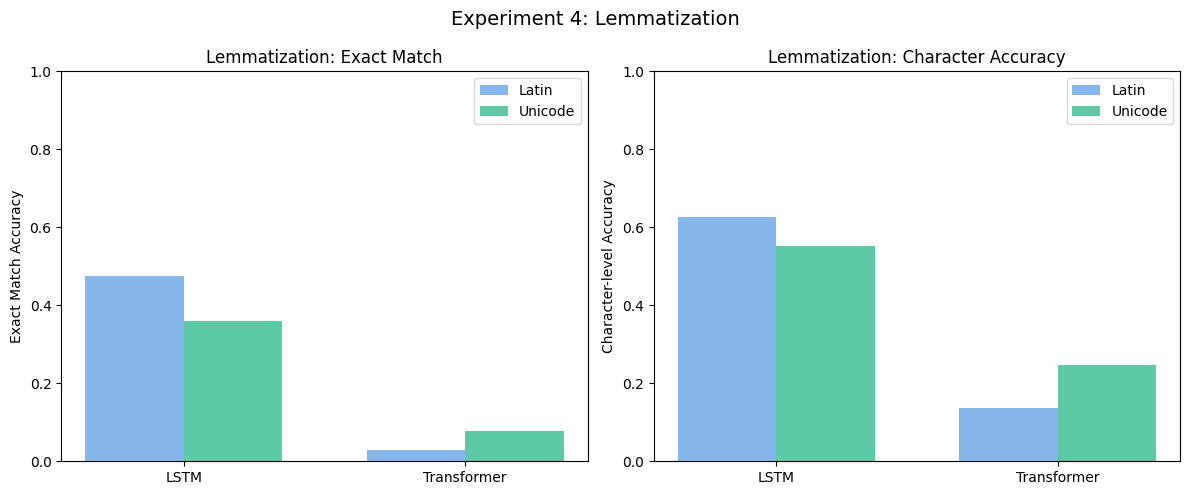

In [16]:
# ============================================================
# 8. RESULTS VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Exact match comparison
models = ['LSTM', 'Transformer']
latin_exact = [results['LSTM Latin']['exact'], results['Transformer Latin']['exact']]
unicode_exact = [results['LSTM Unicode']['exact'], results['Transformer Unicode']['exact']]
x = np.arange(len(models)); w = 0.35

axes[0].bar(x-w/2, latin_exact, w, label='Latin', color='#85B7EB')
axes[0].bar(x+w/2, unicode_exact, w, label='Unicode', color='#5DCAA5')
axes[0].set_xticks(x); axes[0].set_xticklabels(models)
axes[0].set_ylabel('Exact Match Accuracy')
axes[0].set_title('Lemmatization: Exact Match')
axes[0].legend(); axes[0].set_ylim(0, 1)

# Character accuracy
latin_char = [results['LSTM Latin']['char'], results['Transformer Latin']['char']]
unicode_char = [results['LSTM Unicode']['char'], results['Transformer Unicode']['char']]

axes[1].bar(x-w/2, latin_char, w, label='Latin', color='#85B7EB')
axes[1].bar(x+w/2, unicode_char, w, label='Unicode', color='#5DCAA5')
axes[1].set_xticks(x); axes[1].set_xticklabels(models)
axes[1].set_ylabel('Character-level Accuracy')
axes[1].set_title('Lemmatization: Character Accuracy')
axes[1].legend(); axes[1].set_ylim(0, 1)

plt.suptitle('Experiment 4: Lemmatization', fontsize=14)
plt.tight_layout()
plt.savefig('exp4_lemmatization.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ============================================================
# 9. SUMMARY
# ============================================================
print('=' * 60)
print('EXPERIMENT 4: LEMMATIZATION RESULTS')
print('=' * 60)
print(f'Data: {len(lemma_data)} transliteration → lemma pairs')
print(f'Split: 76.5% train / 8.5% val / 15% test')
print()
print(f'{"Model":25s} {"Exact Match":>12s} {"Char Acc":>10s}')
print('-' * 50)
for model_name, r in results.items():
    print(f'{model_name:25s} {r["exact"]:>12.3f} {r["char"]:>10.3f}')
print('=' * 60)

EXPERIMENT 4: LEMMATIZATION RESULTS
Data: 1794 transliteration → lemma pairs
Split: 76.5% train / 8.5% val / 15% test

Model                      Exact Match   Char Acc
--------------------------------------------------
LSTM Latin                       0.474      0.627
LSTM Unicode                     0.359      0.551
Transformer Latin                0.030      0.136
Transformer Unicode              0.078      0.247
